In [2]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr
from pathlib import Path
from datetime import datetime

from pprint import pprint

In [3]:
cwd = Path.cwd()
project_root = cwd.parent
data_path = project_root / "data" / "raw" / "accepted_2007_to_2018q4.csv"/ "accepted_2007_to_2018q4.csv"

In [5]:
data = pd.read_csv(
    filepath_or_buffer=data_path,
    encoding='latin-1',
    sep=",",
    thousands=',',
    na_values=['NA', 'N/A', 'null', 'NULL', '', ' ', 'None'],
    low_memory=False,
    nrows=1000
)

In [6]:
data.shape

(1000, 151)

In [7]:
data.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Columns: 151 entries, id to settlement_term
dtypes: float64(115), int64(1), str(35)
memory usage: 1.2 MB


In [7]:
pd.set_option('display.max_rows', 200)

In [8]:
# let's the null percentages of each of the features
null_pct = (data.isna().sum(axis=0)/len(data))*100
null_pct.sort_values(ascending=False)

member_id                                     100.000000
orig_projected_additional_accrued_interest     99.617331
hardship_end_date                              99.517097
hardship_start_date                            99.517097
hardship_type                                  99.517097
hardship_reason                                99.517097
hardship_status                                99.517097
deferral_term                                  99.517097
hardship_last_payment_amount                   99.517097
hardship_payoff_balance_amount                 99.517097
hardship_loan_status                           99.517097
hardship_dpd                                   99.517097
hardship_length                                99.517097
payment_plan_start_date                        99.517097
hardship_amount                                99.517097
settlement_term                                98.485160
debt_settlement_flag_date                      98.485160
settlement_status              

In [9]:
(data["loan_status"].value_counts()/len(data))*100

loan_status
Fully Paid                                             47.629076
Current                                                38.851533
Charged Off                                            11.879457
Late (31-120 days)                                      0.949573
In Grace Period                                         0.373159
Late (16-30 days)                                       0.192374
Does not meet the credit policy. Status:Fully Paid      0.087937
Does not meet the credit policy. Status:Charged Off     0.033662
Default                                                 0.001769
Name: count, dtype: float64

In [10]:
data.dropna(subset=["loan_status"], inplace=True)

In [ ]:
u_data = data[(data["loan_status"] != "Current") & (data["loan_status"] != "In Grace Period") & (data["loan_status"] != "Late (16-30 days)")].reset_index(drop=True)

In [12]:
u_data["loan_status"].value_counts()

loan_status
Fully Paid                                             1076751
Charged Off                                             268559
Late (31-120 days)                                       21467
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

In [13]:
u_data.shape, data.shape

((1369566, 151), (2260668, 151))

In [14]:
u_data = u_data.copy()
u_data["target"] = np.where(
    (u_data["loan_status"] == "Fully Paid") | 
    (u_data["loan_status"] == "Does not meet the credit policy. Status:Fully Paid"), 
    0, 1
)

In [15]:
class_dist = (u_data["target"].value_counts()/len(u_data))*100

In [16]:
class_dist

target
0    78.765025
1    21.234975
Name: count, dtype: float64

In [17]:
u_data.columns.to_list()

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'last_fico_range_high',
 'last_fico_range_low',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 '

In [18]:
u_data["loan_amnt"].describe()

count    1.369566e+06
mean     1.444877e+04
std      8.737507e+03
min      5.000000e+02
25%      8.000000e+03
50%      1.200000e+04
75%      2.000000e+04
max      4.000000e+04
Name: loan_amnt, dtype: float64

In [19]:
null_pct = (u_data.isna().sum(axis=0)/len(u_data))*100
null_pct.sort_values(ascending=False)

member_id                                     100.000000
orig_projected_additional_accrued_interest     99.619734
hardship_payoff_balance_amount                 99.461216
hardship_amount                                99.461216
hardship_start_date                            99.461216
hardship_reason                                99.461216
hardship_type                                  99.461216
hardship_end_date                              99.461216
payment_plan_start_date                        99.461216
hardship_length                                99.461216
hardship_dpd                                   99.461216
hardship_loan_status                           99.461216
deferral_term                                  99.461216
hardship_status                                99.461216
hardship_last_payment_amount                   99.461216
sec_app_mths_since_last_major_derog            99.454134
sec_app_revol_util                             98.519166
revol_bal_joint                

In [20]:
null_pct["loan_amnt"]

np.float64(0.0)

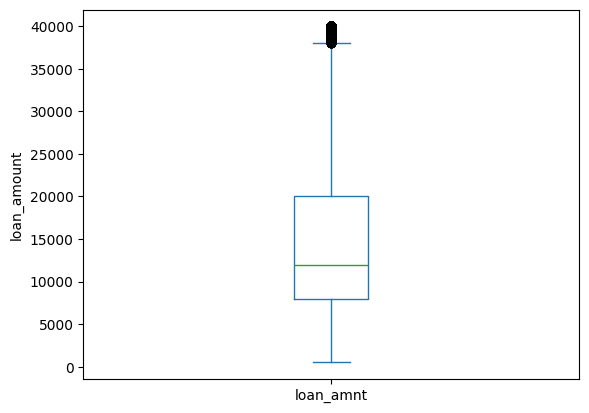

In [21]:
ax = u_data["loan_amnt"].plot.box()
ax.set_ylabel("loan_amount");

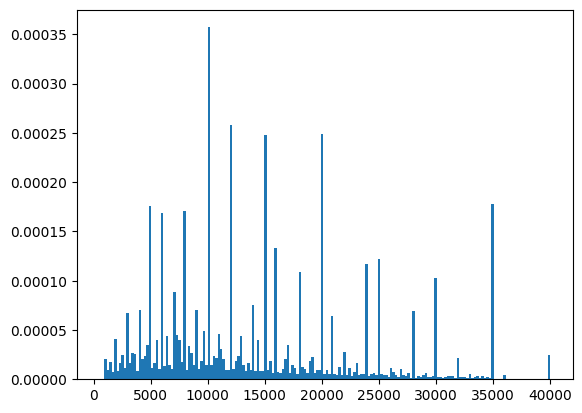

In [22]:
plt.hist(u_data["loan_amnt"], bins='auto', density=True);

In [23]:
ax = pd.cut(u_data["loan_amnt"], 10)
ax.value_counts()

loan_amnt
(8400.0, 12350.0]     297988
(4450.0, 8400.0]      284163
(12350.0, 16300.0]    206965
(16300.0, 20250.0]    166679
(460.5, 4450.0]       117278
(20250.0, 24200.0]     93093
(24200.0, 28150.0]     81249
(32100.0, 36050.0]     63126
(28150.0, 32100.0]     50659
(36050.0, 40000.0]      8366
Name: count, dtype: int64

In [24]:
u_data["loan_amnt"].quantile([0.05, 0.25, 0.5, 0.75, 0.95])

0.05     3200.0
0.25     8000.0
0.50    12000.0
0.75    20000.0
0.95    33000.0
Name: loan_amnt, dtype: float64

<Axes: ylabel='Density'>

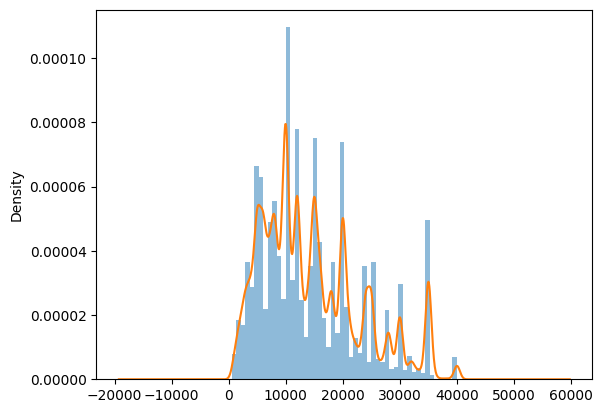

In [25]:
ax = u_data["loan_amnt"].plot.hist(density=True, alpha=0.5, bins=50)
u_data["loan_amnt"].plot.density(ax=ax)

In [26]:
u_data["int_rate"].quantile([0.05, 0.25, 0.5, 0.75, 0.95])

0.05     6.54
0.25     9.75
0.50    12.79
0.75    16.02
0.95    22.20
Name: int_rate, dtype: float64

<Axes: >

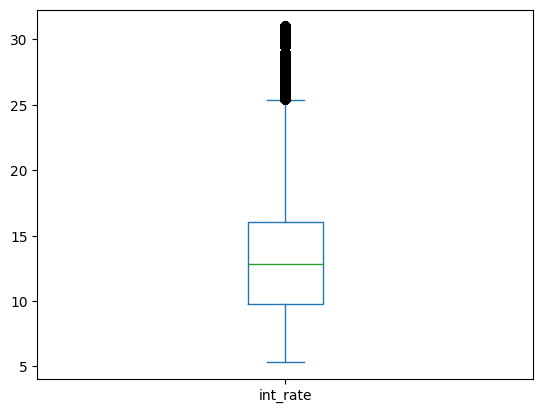

In [27]:
u_data["int_rate"].plot.box()

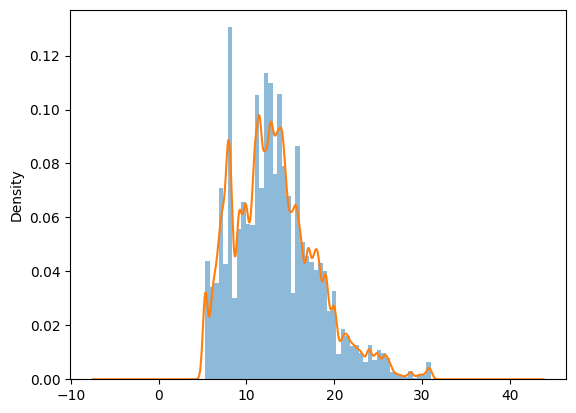

In [28]:
ax = u_data["int_rate"].plot.hist(density=True, alpha=0.5, bins=50)
u_data["int_rate"].plot.density(ax=ax);

does the distribution of loan_amnt or int_rate differ between defaulted and non-defaulted loans?

### loan_amnt

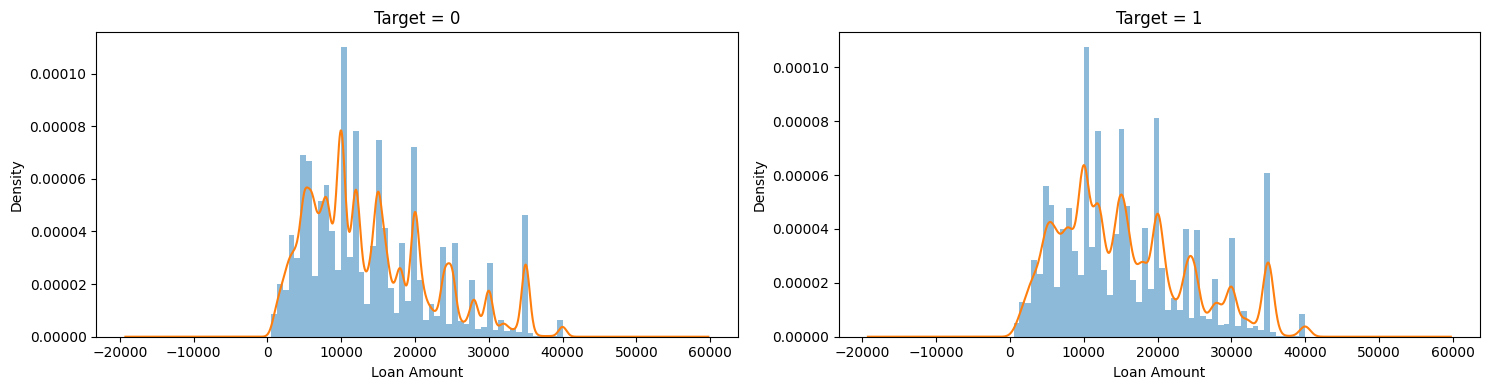

In [29]:
# loan_amnts
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(15, 4))

# target 0
u_data[u_data["target"] == 0]["loan_amnt"].plot.hist(
    ax=ax[0],
    density=True,
    alpha=0.5,
    bins=50,
)

u_data[u_data["target"] == 0]["loan_amnt"].plot.density(
    ax=ax[0]
)

# target 1
u_data[u_data["target"] == 1]["loan_amnt"].plot.hist(
    bins=50,
    density=True,
    alpha=0.5,
    ax=ax[1]
)

u_data[u_data["target"] == 1]["loan_amnt"].plot.density(
    ax=ax[1]
)

ax[0].set_title("Target = 0")
ax[1].set_title("Target = 1")

ax[0].set_xlabel("Loan Amount")
ax[0].set_ylabel("Density")

ax[1].set_xlabel("Loan Amount")
ax[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

### int_rate

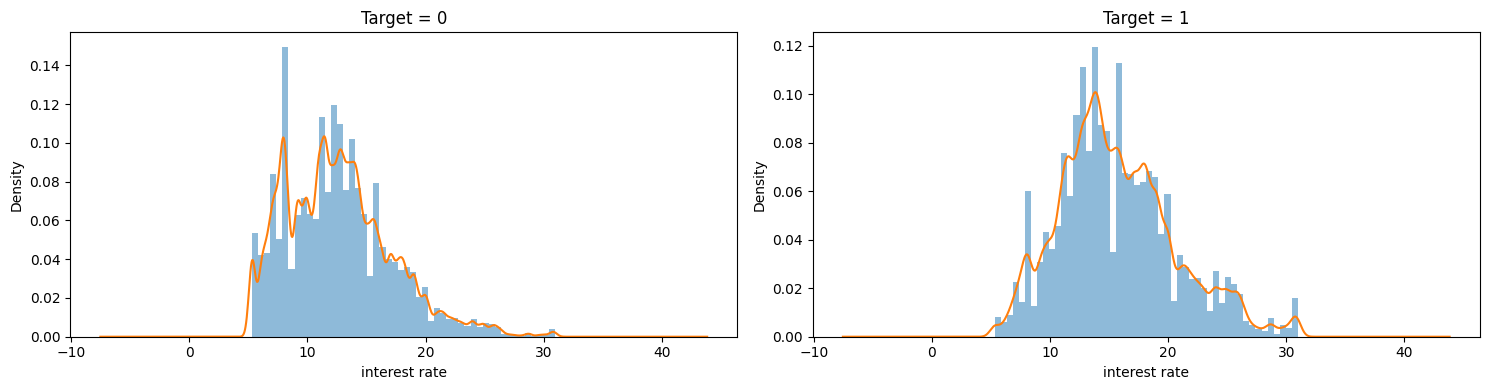

In [30]:
# loan_amnts
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(15, 4))

# target 0
u_data[u_data["target"] == 0]["int_rate"].plot.hist(
    ax=ax[0],
    density=True,
    alpha=0.5,
    bins=50,
)

u_data[u_data["target"] == 0]["int_rate"].plot.density(
    ax=ax[0]
)

# target 1
u_data[u_data["target"] == 1]["int_rate"].plot.hist(
    bins=50,
    density=True,
    alpha=0.5,
    ax=ax[1]
)

u_data[u_data["target"] == 1]["int_rate"].plot.density(
    ax=ax[1]
)

ax[0].set_title("Target = 0")
ax[1].set_title("Target = 1")

ax[0].set_xlabel("interest rate")
ax[0].set_ylabel("Density")

ax[1].set_xlabel("interest rate")
ax[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

### annual_inc

In [31]:
u_data["annual_inc"].describe()

count    1.369562e+06
mean     7.625009e+04
std      7.031078e+04
min      0.000000e+00
25%      4.570000e+04
50%      6.500000e+04
75%      9.000000e+04
max      1.099920e+07
Name: annual_inc, dtype: float64

In [32]:
null_pct["annual_inc"]

np.float64(0.0002920633251701634)

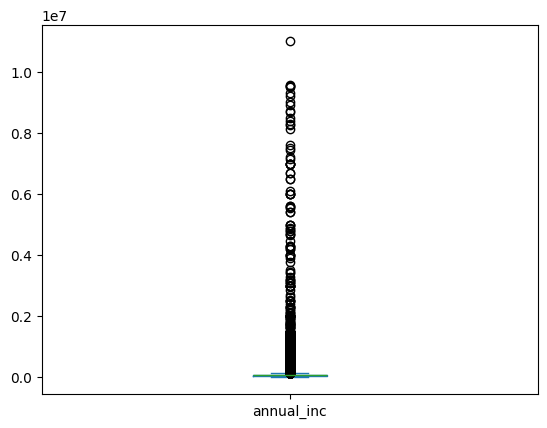

In [34]:
u_data["annual_inc"].plot.box();

In [35]:
u_data["annual_inc"].quantile([0.05, 0.25, 0.5, 0.75, 0.95])

0.05     28000.0
0.25     45700.0
0.50     65000.0
0.75     90000.0
0.95    155000.0
Name: annual_inc, dtype: float64

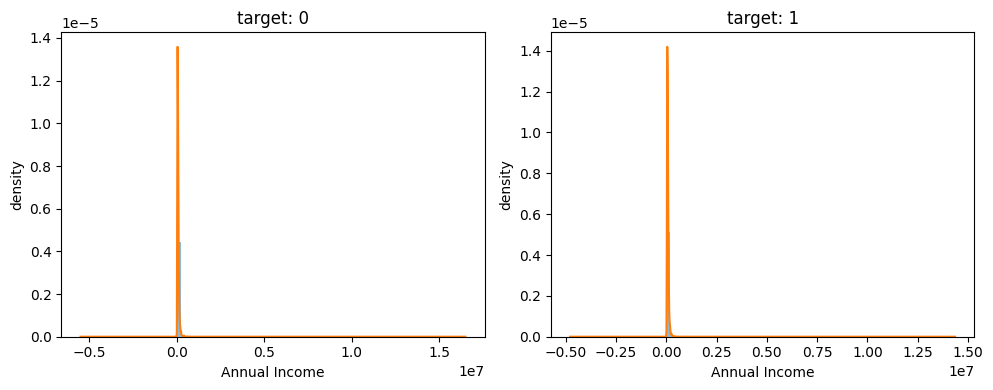

In [36]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(10, 4))

# target 0
u_data[u_data["target"] == 0]["annual_inc"].plot.hist(
    ax=ax[0],
    bins=50,
    alpha=0.5,
    density=True
)

u_data[u_data["target"] == 0]["annual_inc"].plot.density(
    ax=ax[0]
)

# target 1
u_data[u_data["target"] == 1]["annual_inc"].plot.hist(
    ax=ax[1],
    density=True,
    alpha=0.5,
    bins=50
)

u_data[u_data["target"] == 1]["annual_inc"].plot.density(
    ax=ax[1]
)

ax[0].set_xlabel("Annual Income")
ax[0].set_ylabel("density")

ax[1].set_xlabel("Annual Income")
ax[1].set_ylabel("density")

ax[0].set_title("target: 0")
ax[1].set_title("target: 1")

plt.tight_layout()
plt.show()

In [37]:
annual_inc_cuts = pd.cut(u_data["annual_inc"], 10)
annual_inc_cuts.value_counts()

annual_inc
(-10999.2, 1099920.0]      1369283
(1099920.0, 2199840.0]         185
(2199840.0, 3299760.0]          26
(3299760.0, 4399680.0]          16
(4399680.0, 5499600.0]          13
(6599520.0, 7699440.0]          12
(5499600.0, 6599520.0]          11
(8799360.0, 9899280.0]           8
(7699440.0, 8799360.0]           7
(9899280.0, 10999200.0]          1
Name: count, dtype: int64

In [38]:
j_annual_inc_cuts = pd.cut(u_data["annual_inc_joint"], 10)
j_annual_inc_cuts.value_counts()

annual_inc_joint
(7172.0, 191800.0]        25749
(191800.0, 374600.0]       2085
(374600.0, 557400.0]        114
(557400.0, 740200.0]         25
(740200.0, 923000.0]          5
(923000.0, 1105800.0]         3
(1105800.0, 1288600.0]        1
(1288600.0, 1471400.0]        1
(1654200.0, 1837000.0]        1
(1471400.0, 1654200.0]        0
Name: count, dtype: int64

In [47]:
annual_inc_cuts0 = pd.cut(u_data[u_data["target"] == 0]["annual_inc"], 10)
annual_inc_cuts0.value_counts()

annual_inc
(-10999.2, 1099920.0]      1078498
(1099920.0, 2199840.0]         165
(2199840.0, 3299760.0]          20
(3299760.0, 4399680.0]          11
(6599520.0, 7699440.0]          11
(4399680.0, 5499600.0]          10
(5499600.0, 6599520.0]           8
(7699440.0, 8799360.0]           6
(8799360.0, 9899280.0]           5
(9899280.0, 10999200.0]          1
Name: count, dtype: int64

In [48]:
annual_inc_cuts1 = pd.cut(u_data[u_data["target"] == 1]["annual_inc"], 10)
annual_inc_cuts1.value_counts()

annual_inc
(-9573.072, 957307.2]     290765
(957307.2, 1914614.4]         37
(2871921.6, 3829228.8]         6
(4786536.0, 5743843.2]         5
(1914614.4, 2871921.6]         4
(3829228.8, 4786536.0]         4
(8615764.8, 9573072.0]         4
(5743843.2, 6701150.4]         1
(6701150.4, 7658457.6]         1
(7658457.6, 8615764.8]         0
Name: count, dtype: int64

For annual income we can clearly see the distribution of annual incomes are not much different for target 0 and 1.

### avg_cur_bal

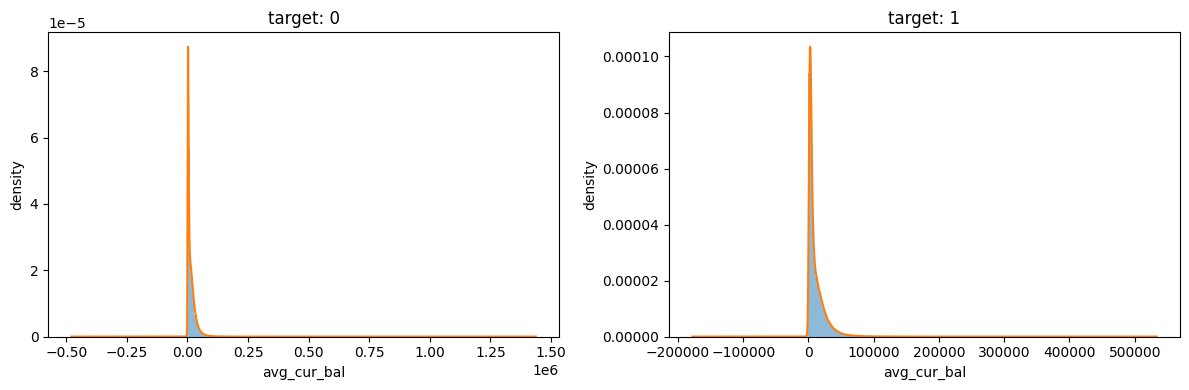

In [43]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(12, 4))

# target 0
u_data[u_data["target"] == 0]["avg_cur_bal"].plot.hist(
    ax=ax[0],
    bins=100,
    alpha=0.5,
    density=True
)

u_data[u_data["target"] == 0]["avg_cur_bal"].plot.density(
    ax=ax[0]
)

# target 1
u_data[u_data["target"] == 1]["avg_cur_bal"].plot.hist(
    ax=ax[1],
    density=True,
    alpha=0.5,
    bins=100
)

u_data[u_data["target"] == 1]["avg_cur_bal"].plot.density(
    ax=ax[1]
)

ax[0].set_xlabel("avg_cur_bal")
ax[0].set_ylabel("density")

ax[1].set_xlabel("avg_cur_bal")
ax[1].set_ylabel("density")

ax[0].set_title("target: 0")
ax[1].set_title("target: 1")

plt.tight_layout()
plt.show()

In [45]:
avg_cur_bal_cuts0 = pd.cut(u_data[u_data["target"] == 0]["avg_cur_bal"], 10)
avg_cur_bal_cuts0.value_counts()

avg_cur_bal
(-958.084, 95808.4]     1014909
(95808.4, 191616.8]        4249
(191616.8, 287425.2]        297
(287425.2, 383233.6]         50
(383233.6, 479042.0]         16
(479042.0, 574850.4]          3
(574850.4, 670658.8]          1
(766467.2, 862275.6]          1
(862275.6, 958084.0]          1
(670658.8, 766467.2]          0
Name: count, dtype: int64

In [46]:
avg_cur_bal_cuts1 = pd.cut(u_data[u_data["target"] == 1]["avg_cur_bal"], 10)
avg_cur_bal_cuts1.value_counts()

avg_cur_bal
(-355.824, 35582.4]     265281
(35582.4, 71164.8]       12786
(71164.8, 106747.2]       1278
(106747.2, 142329.6]       268
(142329.6, 177912.0]        75
(177912.0, 213494.4]        35
(213494.4, 249076.8]        11
(249076.8, 284659.2]         4
(284659.2, 320241.6]         1
(320241.6, 355824.0]         1
Name: count, dtype: int64

for avg current balance we can clearly see the distribution is quite different for target 0 and 1.

In [58]:
u_data[u_data["desc"].notna()]["desc"].iloc[2]

"Lenders,  I have the ability to pay off my current debt but, would like the ability to be able to put some extra money off to the side and build my personal savings account.  The lower interest rate of roughly 7% would enable me to do that.  I'm willing to share my credit report to anyone that is willing to help out. Please consider my application.  Thank you,"

### bc_open_to_buy

In [60]:
bc_open_to_buy0 = pd.cut(u_data[u_data["target"] == 0]["bc_open_to_buy"], 10)
bc_open_to_buy0.value_counts()

bc_open_to_buy
(-559.912, 55991.2]     999811
(55991.2, 111982.4]      23005
(111982.4, 167973.6]      2256
(167973.6, 223964.8]       287
(223964.8, 279956.0]        63
(279956.0, 335947.2]        12
(447929.6, 503920.8]         2
(335947.2, 391938.4]         1
(503920.8, 559912.0]         1
(391938.4, 447929.6]         0
Name: count, dtype: int64

In [61]:
bc_open_to_buy1 = pd.cut(u_data[u_data["target"] == 1]["bc_open_to_buy"], 10)
bc_open_to_buy1.value_counts()

bc_open_to_buy
(-327.512, 32751.2]     268466
(32751.2, 65502.4]        9453
(65502.4, 98253.6]        1481
(98253.6, 131004.8]        362
(131004.8, 163756.0]       105
(163756.0, 196507.2]        24
(196507.2, 229258.4]        16
(229258.4, 262009.6]         8
(262009.6, 294760.8]         8
(294760.8, 327512.0]         1
Name: count, dtype: int64

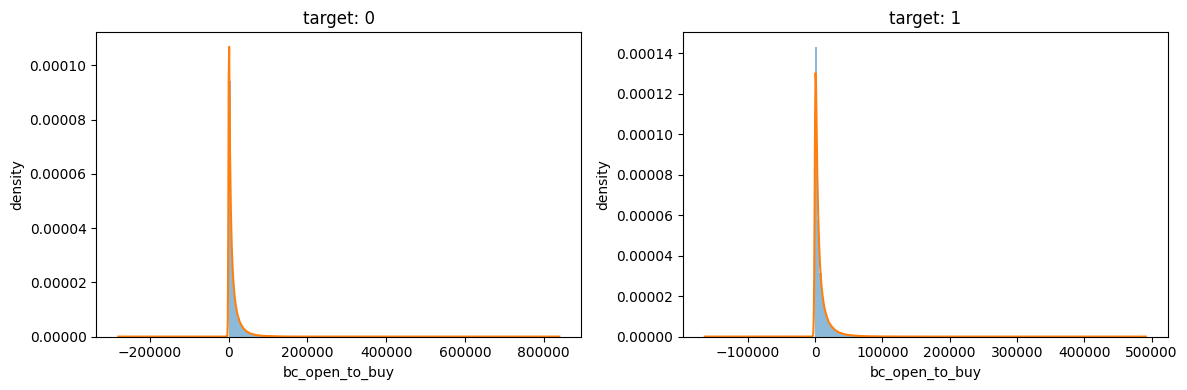

In [62]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(12, 4))

# target 0
u_data[u_data["target"] == 0]["bc_open_to_buy"].plot.hist(
    ax=ax[0],
    bins=100,
    alpha=0.5,
    density=True
)

u_data[u_data["target"] == 0]["bc_open_to_buy"].plot.density(
    ax=ax[0]
)

# target 1
u_data[u_data["target"] == 1]["bc_open_to_buy"].plot.hist(
    ax=ax[1],
    density=True,
    alpha=0.5,
    bins=100
)

u_data[u_data["target"] == 1]["bc_open_to_buy"].plot.density(
    ax=ax[1]
)

ax[0].set_xlabel("bc_open_to_buy")
ax[0].set_ylabel("density")

ax[1].set_xlabel("bc_open_to_buy")
ax[1].set_ylabel("density")

ax[0].set_title("target: 0")
ax[1].set_title("target: 1")

plt.tight_layout()
plt.show()

### Let's not do it one by one, Let's do it all at once

- cuts dict
- plots (differentiating target 0 and target 1)
- box plots
- individual plot

In [20]:
u_data.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_last_payment_amount', 'disbursement_method',
       'debt_settlement_flag', 'debt_settlement_flag_date',
       'settlement_status', 'settlement_date', 'settlement_amount',
       'settlement_percentage', 'settlement_term', 'target'],
      dtype='str', length=152)

In [16]:
def get_cuts(data: pd.DataFrame, no_of_cuts: int) -> dict[str, pd.Series]:
    results = {}
    for column in data.columns:
        if pd.api.types.is_numeric_dtype(data[column]):
            series = data[column].dropna()

            if series.empty or series.nunique() <= 1:
                continue
            results[column] = pd.cut(data[column], no_of_cuts).value_counts()
            
    return results

In [23]:
def get_cont_plots_and_box_plots(data: pd.DataFrame, path: Path):
    for column in data.columns:
        if column in ['id', 'member_id']:
            continue
        
        new_dir = path / f"{column}"
        new_dir.mkdir(parents=True, exist_ok=True)
        
        if pd.api.types.is_numeric_dtype(data[column]):
            col_data = data[column].dropna()
            
            # histogram + density (overlaid, by target)
            fig, ax = plt.subplots(figsize=(10, 4))

            for target_val, color, label in [(0, "steelblue", "target: 0"), (1, "salmon", "target: 1")]:
                subset = data[data["target"] == target_val][column].dropna()
                subset.plot.hist(ax=ax, bins=100, alpha=0.4, density=True, color=color, label=label)
                if subset.nunique() > 1:
                    subset.plot.density(ax=ax, color=color)

            ax.set_xlabel(column)
            ax.set_ylabel("density")
            ax.set_title(f"{column} — distribution by target")
            ax.legend()

            fig.tight_layout()
            fig.savefig(new_dir / f"{column}_compare_targets.png")
            plt.close(fig)
            
            # box plot
            fig, ax = plt.subplots(figsize=(10, 8))

            ax.boxplot(col_data)
            ax.set_title(f"{column} box plot")

            fig.tight_layout()
            fig.savefig(new_dir / f"{column}_box_plot.png")
            plt.close(fig)
            
            # standalone plot
            fig, ax = plt.subplots(figsize=(10, 6))

            col_data.plot.hist(ax=ax, density=True, alpha=0.5, bins=50)
            if col_data.nunique() > 1:
                col_data.plot.density(ax=ax)

            fig.tight_layout()
            fig.savefig(new_dir / f"{column}_plot.png")
            plt.close(fig)
            
        elif pd.api.types.is_object_dtype(data[column]):
            fig, ax = plt.subplots(figsize=(10, 8))

            counts = data[column].value_counts()
            ax.barh(counts.index, counts.values)

            fig.tight_layout()
            fig.savefig(new_dir / f"{column}_value_counts.png")
            plt.close(fig)

In [99]:
cuts = get_cuts(data=u_data, no_of_cuts=10)
cuts_dir = project_root / "data" / "processed" / "cuts"
cuts_dir.mkdir(parents=True, exist_ok=True)
with open(str(cuts_dir / "numeric_columns_cuts.pkl"), "wb") as f:
    pickle.dump(cuts, f)

In [24]:
plots_path = project_root / "data" / "plots" / "eda"
plots_path.mkdir(parents=True, exist_ok=True)

get_cont_plots_and_box_plots(data=u_data, path=plots_path)

In [24]:
numeric_cols = u_data.select_dtypes(include='number').columns.tolist()

In [26]:
correlations = u_data[numeric_cols].corr()["target"].sort_values(ascending=False)
correlations

target                                        1.000000
recoveries                                    0.481679
collection_recovery_fee                       0.457210
int_rate                                      0.263009
hardship_dpd                                  0.244928
out_prncp                                     0.194811
out_prncp_inv                                 0.194801
orig_projected_additional_accrued_interest    0.174669
hardship_amount                               0.165148
hardship_payoff_balance_amount                0.158215
total_rec_late_fee                            0.153840
sec_app_inq_last_6mths                        0.148801
sec_app_revol_util                            0.143684
dti_joint                                     0.141948
sec_app_collections_12_mths_ex_med            0.104177
acc_open_past_24mths                          0.099789
hardship_last_payment_amount                  0.091422
num_tl_op_past_12m                            0.085194
dti       

In [30]:
correlations = {}
for col in numeric_cols:
    correlations[col] = pointbiserialr(u_data[col], u_data["target"]).statistic.item()

/Users/ak007/SML/Credit-Risk-Default-Prediction-System/.venv/lib/python3.11/site-packages/scipy/stats/_stats_py.py:5523: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)


In [31]:
correlations

{'member_id': nan,
 'loan_amnt': 0.071446694338588,
 'funded_amnt': 0.07151089676917763,
 'funded_amnt_inv': 0.07111191483928825,
 'int_rate': 0.26300946003557013,
 'installment': 0.05661367348917078,
 'annual_inc': nan,
 'dti': nan,
 'delinq_2yrs': nan,
 'fico_range_low': -0.12957640836645043,
 'fico_range_high': -0.12957500908658937,
 'inq_last_6mths': nan,
 'mths_since_last_delinq': nan,
 'mths_since_last_record': nan,
 'open_acc': nan,
 'pub_rec': nan,
 'revol_bal': -0.020639137741314567,
 'revol_util': nan,
 'total_acc': nan,
 'out_prncp': 0.19481087449859763,
 'out_prncp_inv': 0.19480071555083056,
 'total_pymnt': -0.3210631290897785,
 'total_pymnt_inv': -0.32049103095535564,
 'total_rec_prncp': -0.4453166909469195,
 'total_rec_int': 0.06340090980384191,
 'total_rec_late_fee': 0.15384040785563668,
 'recoveries': 0.481679223071081,
 'collection_recovery_fee': 0.4572103192683357,
 'last_pymnt_amnt': -0.3564565819942722,
 'last_fico_range_high': -0.6674492515908689,
 'last_fico_range

In [34]:
u_data["grade"].unique()

<StringArray>
['C', 'B', 'F', 'A', 'E', 'D', 'G']
Length: 7, dtype: str

In [38]:
grade = u_data["grade"].replace({'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7})

In [39]:
grade

0          3
1          3
2          2
4          6
5          3
          ..
2260688    2
2260690    3
2260691    3
2260692    3
2260697    3
Name: grade, Length: 1369566, dtype: object

In [40]:
## Let's check some grey area features.
u_data["int_rate"].corr(grade)

np.float64(0.952105295840675)

In [41]:
u_data["sub_grade"].unique()

<StringArray>
['C4', 'C1', 'B4', 'F1', 'C3', 'B2', 'B1', 'A2', 'B5', 'C2', 'E2', 'A4', 'E3',
 'C5', 'A1', 'D4', 'F3', 'D1', 'B3', 'D3', 'D5', 'A5', 'F2', 'E4', 'D2', 'E1',
 'F5', 'E5', 'A3', 'G2', 'G1', 'G3', 'G4', 'F4', 'G5']
Length: 35, dtype: str

In [44]:
sub_grade = {}
for sg in u_data["sub_grade"].unique():
    if 'A' in sg:
        sub_grade[sg] = 1 + int(sg[1])/10
    if 'B' in sg:
        sub_grade[sg] = 2 + int(sg[1])/10
    if 'C' in sg:
        sub_grade[sg] = 3 + int(sg[1])/10
    if 'D' in sg:
        sub_grade[sg] = 4 + int(sg[1])/10
    if 'E' in sg:
        sub_grade[sg] = 5 + int(sg[1])/10
    if 'F' in sg:
        sub_grade[sg] = 6 + int(sg[1])/10
    if 'G' in sg:
        sub_grade[sg] = 7 + int(sg[1])/10

In [46]:
sub_grade = u_data["sub_grade"].replace(sub_grade)

In [47]:
sub_grade

0          3.4
1          3.1
2          2.4
4          6.1
5          3.3
          ... 
2260688    2.2
2260690    3.3
2260691    3.4
2260692    3.1
2260697    3.4
Name: sub_grade, Length: 1369566, dtype: object

In [48]:
u_data["int_rate"].corr(sub_grade)

np.float64(0.9696083100173117)

In [ ]:
u_data["int_rate"].corr(u_data["installment"])

np.float64(0.15534407772342954)

In [51]:
u_data["installment"].corr(grade)

np.float64(0.1446158342149858)

In [52]:
u_data["installment"].corr(sub_grade)

np.float64(0.14796766551478477)

Ok, we will remove int_rate, grade, sub_grade but we will keep installment

In [53]:
u_data["funded_amnt"].corr(u_data["funded_amnt_inv"])

np.float64(0.9988022890719472)

In [54]:
u_data["loan_amnt"].corr(u_data["funded_amnt"])

np.float64(0.999554496529099)

In [55]:
u_data["acc_now_delinq"].corr(u_data["delinq_amnt"])

np.float64(0.1672915613896044)

In [57]:
u_data[['dti', 'annual_inc']].quantile([0.25, 0.5, 0.75, 0.95, 0.99, 0.999])

,dti,annual_inc
0.250,11.79000,45700.0
0.500,17.62000,65000.0
0.750,24.08000,90000.0
0.950,33.02000,155000.0
0.990,38.56000,252000.0
0.999,68.32833,580000.0


In [20]:
u_data["issue_d"] = pd.to_datetime(u_data["issue_d"], format="%b-%Y")

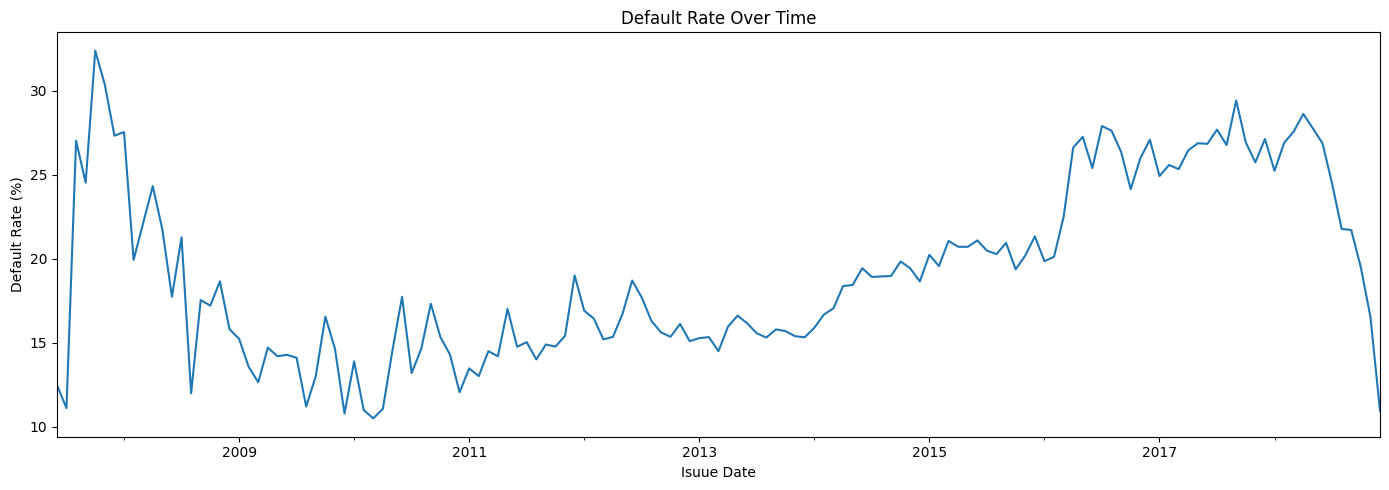

In [23]:
# let's Group by date and see how default rate as each month of the year does by
default_rate = u_data.groupby(by="issue_d")["target"].mean() * 100
default_rate.plot(figsize=(14, 5), title="Default Rate Over Time")
plt.ylabel("Default Rate (%)")
plt.xlabel("Isuue Date")
plt.tight_layout()

In [28]:
u_data["issue_d"]

0         2015-12-01
1         2015-12-01
2         2015-12-01
3         2015-12-01
4         2015-12-01
             ...    
1369561   2016-10-01
1369562   2016-10-01
1369563   2016-10-01
1369564   2016-10-01
1369565   2016-10-01
Name: issue_d, Length: 1369566, dtype: datetime64[us]

In [37]:
mask = (u_data["issue_d"] > datetime(2016, 1, 1)) & (u_data["issue_d"] < datetime(2017, 1, 1))
u_data[mask]["loan_status"].value_counts()

loan_status
Fully Paid            201918
Charged Off            62780
Late (31-120 days)      4326
Default                   10
Name: count, dtype: int64

In [32]:
u_data["loan_status"].unique()

<StringArray>
[                                         'Fully Paid',
                                         'Charged Off',
                                  'Late (31-120 days)',
                                             'Default',
  'Does not meet the credit policy. Status:Fully Paid',
 'Does not meet the credit policy. Status:Charged Off']
Length: 6, dtype: str

Since the recent loans didn't much time to mature, we will have to drop the recent loans from the data. It's sad we have loss this potentially very imp data, but later we will try to use it in the end or as a part of further improvement in the project later using techinques like urvival analysis or more practically time-to-default modeling, But for now this is the plan:
- 2007-2014 train, 2015 val, 2016-2017 test

In [40]:
# missing value analysis
null_pct[null_pct > 0].sort_values(ascending=False)

member_id                                     100.000000
orig_projected_additional_accrued_interest     99.619734
hardship_dpd                                   99.461216
hardship_type                                  99.461216
hardship_reason                                99.461216
hardship_status                                99.461216
deferral_term                                  99.461216
hardship_amount                                99.461216
hardship_start_date                            99.461216
hardship_end_date                              99.461216
hardship_length                                99.461216
payment_plan_start_date                        99.461216
hardship_loan_status                           99.461216
hardship_payoff_balance_amount                 99.461216
hardship_last_payment_amount                   99.461216
sec_app_mths_since_last_major_derog            99.454134
sec_app_revol_util                             98.519166
revol_bal_joint                

In [42]:
u_data.select_dtypes(include='str').columns.tolist()

['id',
 'term',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'verification_status',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'earliest_cr_line',
 'initial_list_status',
 'last_pymnt_d',
 'next_pymnt_d',
 'last_credit_pull_d',
 'application_type',
 'verification_status_joint',
 'sec_app_earliest_cr_line',
 'hardship_flag',
 'hardship_type',
 'hardship_reason',
 'hardship_status',
 'hardship_start_date',
 'hardship_end_date',
 'payment_plan_start_date',
 'hardship_loan_status',
 'disbursement_method',
 'debt_settlement_flag',
 'debt_settlement_flag_date',
 'settlement_status',
 'settlement_date']

In [46]:
u_data.shape

(1369566, 152)

In [38]:
null_pct["term"]

np.float64(0.0)

In [44]:
u_data["term"].value_counts()

term
36 months    1035680
60 months     333886
Name: count, dtype: int64

In [48]:
u_data.groupby(by='term')["target"].mean()*100

term
36 months    17.032288
60 months    34.271278
Name: target, dtype: float64

term takes only two values:
- 36 months: default rate : 17%
- 60 months: default rate : 34%

null values percentage: 0%

In [49]:
null_pct["emp_title"]

np.float64(6.423129662973526)

In [24]:
u_data["emp_title"].value_counts()

emp_title
Teacher                       21604
Manager                       19847
Owner                         10678
Registered Nurse               8938
RN                             8670
                              ...  
Foster care worker                1
Group enviromental Manager        1
personal investor                 1
Sr. Photo Producer                1
Exec Dir Internal Audit           1
Name: count, Length: 383313, dtype: int64

In [25]:
default_rate_emp_type = (u_data.groupby(by="emp_title")["target"].mean()*100).sort_values(ascending=False)

In [29]:
pd.cut(default_rate_emp_type, 10).value_counts()

target
(-0.1, 10.0]     283384
(90.0, 100.0]     64821
(40.0, 50.0]      11613
(30.0, 40.0]       7421
(10.0, 20.0]       7411
(20.0, 30.0]       6524
(60.0, 70.0]       1433
(50.0, 60.0]        395
(70.0, 80.0]        301
(80.0, 90.0]         10
Name: count, dtype: int64

emp_title: It takes 383313 unique values, among these, This is status of no of emp_type for each percentage range of default rate:
- (-0.1, 10.0]  - 283384
- (90.0, 100.0] - 64821
- (40.0, 50.0]  - 11613
- (30.0, 40.0]  - 7421
- (10.0, 20.0]  - 7411
- (20.0, 30.0]  - 6524
- (60.0, 70.0]  - 1433
- (50.0, 60.0]  - 395
- (70.0, 80.0]  - 301
- (80.0, 90.0]  - 10

null_value_pct: 6.42%

In [39]:
null_pct["emp_length"]

np.float64(5.870545851751577)

In [33]:
u_data["emp_length"].value_counts()

emp_length
10+ years    449252
2 years      124063
< 1 year     110566
3 years      109662
1 year        90285
5 years       85645
4 years       82176
6 years       63798
8 years       61566
7 years       60495
9 years       51657
Name: count, dtype: int64

In [34]:
(u_data.groupby(by='emp_length')["target"].mean()*100).sort_values(ascending=False)

emp_length
< 1 year     22.000434
1 year       21.855236
3 years      21.299083
4 years      21.138775
2 years      21.092509
8 years      20.936881
9 years      20.899394
5 years      20.858194
6 years      20.539829
7 years      20.535581
10+ years    19.987891
Name: target, dtype: float64

emp_length takes 11 unique values with following default rates:
- < 1 year     : 22.000434
- 1 year       : 21.855236
- 3 years      : 21.299083
- 4 years      : 21.138775
- 2 years      : 21.092509
- 8 years      : 20.936881
- 9 years      : 20.899394
- 5 years      : 20.858194
- 6 years      : 20.539829
- 7 years      : 20.535581
- 10+ years    : 19.987891

null percentage: 5.87%

In [40]:
null_pct["pymnt_plan"]

np.float64(0.0)

In [35]:
u_data["pymnt_plan"].value_counts()

pymnt_plan
n    1368963
y        603
Name: count, dtype: int64

In [36]:
default_rate_pymnt_plan = (u_data.groupby(by="pymnt_plan")["target"].mean()*100).sort_values(ascending=False)

In [37]:
default_rate_pymnt_plan

pymnt_plan
y    100.000000
n     21.200281
Name: target, dtype: float64

pymnt_plan takes only two values `y` and `n`, with follwing default rates:
- y    : 100.000000
- n    : 21.200281

null percentage: 0%

In [41]:
null_pct['home_ownership']

np.float64(0.0)

In [42]:
u_data['home_ownership'].value_counts()

home_ownership
MORTGAGE    676160
RENT        545154
OWN         147713
ANY            304
OTHER          182
NONE            53
Name: count, dtype: int64

In [43]:
default_rate_home = (u_data.groupby(by='home_ownership')['target'].mean()*100).sort_values(ascending=False)
default_rate_home

home_ownership
RENT        24.561133
ANY         24.342105
OWN         22.074564
OTHER       20.879121
MORTGAGE    18.369025
NONE        15.094340
Name: target, dtype: float64

home_ownership takes 6 unique values with following default_rate:
- RENT        : 24.561133
- ANY         : 24.342105
- OWN         : 22.074564
- OTHER       : 20.879121
- MORTGAGE    : 18.369025
- NONE        : 15.094340

null percentage: 0% but i think NONE is also actually null

In [44]:
null_pct['verification_status']

np.float64(0.0)

In [ ]:
u_data['verification_status'].value_counts()

verification_status
Source Verified    530628
Verified           425678
Not Verified       413260
Name: count, dtype: int64

In [46]:
default_rate_verification = (u_data.groupby(by='verification_status')['target'].mean()*100).sort_values(ascending=False)
default_rate_verification

verification_status
Verified           25.060022
Source Verified    22.309226
Not Verified       15.915646
Name: target, dtype: float64

verification_status takes 3 unique values with following default rates:
- Verified           : 25.060022
- Source Verified    : 22.309226
- Not Verified       : 15.915646

null percentage: 0%

In [47]:
null_pct['purpose']

np.float64(0.0)

In [48]:
u_data['purpose'].value_counts()

purpose
debt_consolidation    793917
credit_card           299639
home_improvement       89162
other                  79905
major_purchase         30118
small_business         15916
medical                15908
car                    14844
moving                  9704
vacation                9245
house                   7485
wedding                 2350
renewable_energy         950
educational              423
Name: count, dtype: int64

In [49]:
default_rate_purpose = (u_data.groupby(by='purpose')['target'].mean()*100).sort_values(ascending=False)
default_rate_purpose

purpose
small_business        31.358382
renewable_energy      24.842105
moving                24.804204
house                 23.861055
medical               23.290168
other                 22.666917
debt_consolidation    22.395540
educational           20.803783
vacation              20.605733
major_purchase        20.140780
home_improvement      19.085485
credit_card           18.045381
car                   15.824576
wedding               12.425532
Name: target, dtype: float64

purpose takes 14 unique values with following default rates:
- small_business        : 31.358382
- renewable_energy      : 24.842105
- moving                : 24.804204
- house                 : 23.861055
- medical               : 23.290168
- other                 : 22.666917
- debt_consolidation    : 22.395540
- educational           : 20.803783
- vacation              : 20.605733
- major_purchase        : 20.140780
- home_improvement      : 19.085485
- credit_card           : 18.045381
- car                   : 15.824576
- wedding               : 12.425532

null percentage: 0%

In [50]:
null_pct['title']

np.float64(1.2371802454208123)

In [51]:
u_data['title'].value_counts()

title
Debt consolidation             673279
Credit card refinancing        253869
Home improvement                76512
Other                           68375
Major purchase                  24612
                                ...  
PAYROLL LOAN                        1
3yr conolidation                    1
takeitaway                          1
Creditt Card Loan                   1
debt reduction/hone updates         1
Name: count, Length: 63153, dtype: int64

In [52]:
default_rate_title = (u_data.groupby(by='title')['target'].mean()*100).sort_values(ascending=False)
default_rate_title

title
Debtcons                                  100.0
abounding                                 100.0
abc                                       100.0
a-float                                   100.0
a way out                                 100.0
                                          ...  
Graduate Student Credit Card Refinance      0.0
Graduate Student Debt Consolidation         0.0
Graduate Student debt consolidation         0.0
Graduate loan payoff and moving!            0.0
Ã®ÂÂÃ®ÂÂMY FIRST CAR Ã®ÂÂÃ®ÂÂ       0.0
Name: target, Length: 63153, dtype: float64

In [53]:
pd.cut(default_rate_title, 10).value_counts()

target
(-0.1, 10.0]     50949
(90.0, 100.0]     8360
(40.0, 50.0]      1188
(10.0, 20.0]      1111
(30.0, 40.0]       737
(20.0, 30.0]       690
(60.0, 70.0]        82
(70.0, 80.0]        19
(50.0, 60.0]        17
(80.0, 90.0]         0
Name: count, dtype: int64

title has 63153 unique values and here is the no of title with these default rate percentage range:
- (-0.1, 10.0]     : 50949
- (90.0, 100.0]    :  8360
- (40.0, 50.0]     :  1188
- (10.0, 20.0]     :  1111
- (30.0, 40.0]     :   737
- (20.0, 30.0]     :   690
- (60.0, 70.0]     :    82
- (70.0, 80.0]     :    19
- (50.0, 60.0]     :    17
- (80.0, 90.0]     :     0

null percentage: 1.23%

In [54]:
null_pct['zip_code']

np.float64(7.301583129254084e-05)

In [55]:
u_data['zip_code'].value_counts()

zip_code
945xx    15217
750xx    14704
112xx    14168
606xx    12627
300xx    12355
         ...  
552xx        1
698xx        1
896xx        1
205xx        1
525xx        1
Name: count, Length: 946, dtype: int64

In [56]:
default_rate_zip = (u_data.groupby(by='zip_code')['target'].mean()*100).sort_values(ascending=False)
default_rate_zip

zip_code
568xx    100.0
205xx    100.0
858xx    100.0
516xx    100.0
682xx    100.0
         ...  
966xx      0.0
527xx      0.0
552xx      0.0
340xx      0.0
771xx      0.0
Name: target, Length: 946, dtype: float64

In [58]:
pd.cut(default_rate_zip, 10).value_counts()

target
(20.0, 30.0]     563
(10.0, 20.0]     287
(-0.1, 10.0]      44
(30.0, 40.0]      27
(40.0, 50.0]      12
(90.0, 100.0]     10
(70.0, 80.0]       2
(60.0, 70.0]       1
(50.0, 60.0]       0
(80.0, 90.0]       0
Name: count, dtype: int64

In [60]:
bins = pd.cut(default_rate_zip, 10)

result = (
    default_rate_zip
    .groupby(bins)
    .apply(lambda x: list(x.index))
)

result

target
(-0.1, 10.0]     [022xx, 830xx, 045xx, 987xx, 854xx, 909xx, 269...
(10.0, 20.0]     [965xx, 007xx, 267xx, 588xx, 575xx, 098xx, 138...
(20.0, 30.0]     [246xx, 169xx, 414xx, 215xx, 464xx, 084xx, 393...
(30.0, 40.0]     [835xx, 736xx, 739xx, 683xx, 415xx, 746xx, 569...
(40.0, 50.0]     [901xx, 504xx, 503xx, 204xx, 203xx, 709xx, 663...
(60.0, 70.0]                                               [345xx]
(70.0, 80.0]                                        [692xx, 502xx]
(90.0, 100.0]    [568xx, 205xx, 858xx, 516xx, 682xx, 938xx, 524...
Name: target, dtype: object

zip_code takes 946 values with following counts following default_rates:
- (20.0, 30.0]     : 563
- (10.0, 20.0]     : 287
- (-0.1, 10.0]     :  44
- (30.0, 40.0]     :  27
- (40.0, 50.0]     :  12
- (90.0, 100.0]    :  10
- (70.0, 80.0]     :   2
- (60.0, 70.0]     :   1
- (50.0, 60.0]     :   0
- (80.0, 90.0]     :   0

null percentage: 7.301583129254084e-05%

In [61]:
null_pct['addr_state']

np.float64(0.0)

In [62]:
u_data['addr_state'].value_counts()

addr_state
CA    199852
TX    112216
NY    112145
FL     97682
IL     52542
NJ     49354
PA     46360
OH     44491
GA     44154
VA     38725
NC     38438
MI     35848
AZ     33225
MD     31911
MA     31532
CO     30084
WA     29601
MN     24356
IN     22066
MO     21715
TN     20725
NV     20581
CT     20117
WI     18130
AL     16946
OR     16618
SC     16247
LA     15777
KY     13055
OK     12516
KS     11404
AR     10238
UT     10179
NM      7491
HI      6871
MS      6802
NH      6567
RI      5970
WV      4928
MT      3873
DE      3859
NE      3683
DC      3526
AK      3246
WY      2962
SD      2806
VT      2688
ME      2064
ID      1737
ND      1649
IA        14
Name: count, dtype: int64

In [63]:
default_rate_addr_state = (u_data.groupby(by='addr_state')['target'].mean()*100).sort_values(ascending=False)
default_rate_addr_state

addr_state
MS    28.359306
NE    27.070323
AR    25.415120
AL    24.991148
OK    24.800256
LA    24.408950
NY    23.474074
NV    23.050386
FL    22.979669
MD    22.847921
ND    22.741055
MO    22.698595
TN    22.644150
IN    22.641167
NM    22.560406
NJ    22.350772
SD    22.344975
KY    22.121792
NC    22.056298
PA    22.031924
MI    21.507476
OH    21.496482
HI    21.452481
IA    21.428571
VA    21.195610
TX    21.172560
MN    20.918870
AK    20.918053
ID    20.898100
DE    20.860327
CA    20.835919
AZ    20.812641
MA    20.255613
WI    19.911748
GA    19.674322
IL    19.167523
RI    19.112228
CT    18.725456
UT    18.086256
MT    17.815647
WY    17.758271
KS    17.756927
SC    17.510925
WA    16.830512
CO    16.513761
WV    16.213474
NH    15.897670
OR    15.411000
ME    15.261628
VT    15.029762
DC    14.237096
Name: target, dtype: float64

In [64]:
len(default_rate_addr_state)

51

addr_state takes 51 unique values with following default rates:

- MS    : 28.359306
- NE    : 27.070323
- AR    : 25.415120
- AL    : 24.991148
- OK    : 24.800256
- LA    : 24.408950
- NY    : 23.474074
- NV    : 23.050386
- FL    : 22.979669
- MD    : 22.847921
- ND    : 22.741055
- MO    : 22.698595
- TN    : 22.644150
- IN    : 22.641167
- NM    : 22.560406
- NJ    : 22.350772
- SD    : 22.344975
- KY    : 22.121792
- NC    : 22.056298
- PA    : 22.031924
- MI    : 21.507476
- OH    : 21.496482
- HI    : 21.452481
- IA    : 21.428571
- VA    : 21.195610
- TX    : 21.172560
- MN    : 20.918870
- AK    : 20.918053
- ID    : 20.898100
- DE    : 20.860327
- CA    : 20.835919
- AZ    : 20.812641
- MA    : 20.255613
- WI    : 19.911748
- GA    : 19.674322
- IL    : 19.167523
- RI    : 19.112228
- CT    : 18.725456
- UT    : 18.086256
- MT    : 17.815647
- WY    : 17.758271
- KS    : 17.756927
- SC    : 17.510925
- WA    : 16.830512
- CO    : 16.513761
- WV    : 16.213474
- NH    : 15.897670
- OR    : 15.411000
- ME    : 15.261628
- VT    : 15.029762
- DC    : 14.237096

null percentage: 0%

In [65]:
null_pct['earliest_cr_line']

np.float64(0.0021174591074836846)

In [66]:
u_data['earliest_cr_line'].value_counts()

earliest_cr_line
Aug-2001    9515
Aug-2002    9207
Sep-2003    9179
Sep-2004    9013
Oct-2001    8976
            ... 
Nov-1950       1
Nov-1955       1
Feb-1957       1
Feb-1960       1
Dec-1951       1
Name: count, Length: 739, dtype: int64

In [69]:
u_data['earliest_cr_line'] = pd.to_datetime(u_data['earliest_cr_line'], format="%b-%Y")

In [71]:
latest_date = max(u_data['earliest_cr_line'])
latest_date

Timestamp('2015-10-01 00:00:00')

In [73]:
(latest_date - u_data['earliest_cr_line']).unique()

<TimedeltaArray>
[ '4444 days',  '5783 days',  '5539 days',  '6331 days', '10227 days',
  '9253 days',  '6086 days',  '4931 days',  '7639 days',  '7061 days',
 ...
          NaT, '21184 days', '22614 days', '22007 days', '22798 days',
 '23710 days', '21884 days', '21426 days', '20331 days', '23315 days']
Length: 740, dtype: timedelta64[us]

earliest_cr_line takes 740 unique dates which are the credit history of the borrower. will do further analysis during tranformation, cause the dates are str and we will have to convert in days or something.

null percentage: 0.00211%

In [74]:
null_pct['initial_list_status']

np.float64(0.0)

In [75]:
u_data['initial_list_status'].value_counts()

initial_list_status
w    800896
f    568670
Name: count, dtype: int64

In [76]:
default_rate_ils = (u_data.groupby(by='initial_list_status')['target'].mean()*100).sort_values(ascending=False)
default_rate_ils

initial_list_status
w    21.891232
f    20.310725
Name: target, dtype: float64

initial_list_status takes 2 unique values with following default rates:
- w    : 21.891232
- f    : 20.310725

In [78]:
null_pct['application_type']

np.float64(0.0)

In [79]:
u_data['application_type'].value_counts()

application_type
Individual    1341582
Joint App       27984
Name: count, dtype: int64

In [81]:
default_rate_app_type = (u_data.groupby(by='application_type')['target'].mean()*100).sort_values(ascending=False)
default_rate_app_type

application_type
Joint App     30.474557
Individual    21.042247
Name: target, dtype: float64

application_type takes 2 values with following default rates:
- Joint App     : 30.474557
- Individual    : 21.042247

null percentage : 0%

In [82]:
null_pct['verification_status_joint']

np.float64(97.97344560247552)

In [ ]:
u_data['verification_status_joint'].value_counts()

verification_status_joint
Not Verified       15778
Source Verified     6985
Verified            4992
Name: count, dtype: int64

In [84]:
default_rate_ver_joint = (u_data.groupby(by='verification_status_joint')['target'].mean()*100).sort_values(ascending=False)
default_rate_ver_joint

verification_status_joint
Verified           35.957532
Source Verified    34.931997
Not Verified       26.891875
Name: target, dtype: float64

verification_status_joint takes 3 values with follwing default rates:
- Verified           : 35.957532
- Source Verified    : 34.931997
- Not Verified       : 26.891875

null percentage: 97.97%

In [85]:
null_pct['sec_app_earliest_cr_line']

np.float64(98.49236911547162)

In [86]:
u_data['sec_app_earliest_cr_line'].value_counts()

sec_app_earliest_cr_line
Aug-2006    205
Aug-2005    194
Sep-2006    187
Jul-2006    175
Aug-2004    171
           ... 
Dec-1971      1
May-1977      1
Jun-1981      1
Jun-1979      1
Sep-1977      1
Name: count, Length: 582, dtype: int64

sec_app_earliest_cr_line takes 582 unique dates which are the credit history of the joint borrowers. will do further analysis during tranformation, cause the dates are str and we will have to convert in days or something.

null percentage: 98.49%

In [88]:
null_pct['disbursement_method']

np.float64(0.0)

In [ ]:
u_data['disbursement_method'].value_counts()

disbursement_method
Cash         1362127
DirectPay       7439
Name: count, dtype: int64

In [90]:
default_rate_dis_method = (u_data.groupby(by='disbursement_method')['target'].mean()*100).sort_values(ascending=False)
default_rate_dis_method

disbursement_method
DirectPay    25.863691
Cash         21.209696
Name: target, dtype: float64

disbursement_method takes 2 values with following default rates:
- DirectPay    : 25.863691
- Cash         : 21.209696

null percentage: 0%

I have a made a huge mistake, by dropping the 'current' status loans we have oversampled the default loans, for the recent years, we have to correct that, we have to split the data into training set, val set, test set, in a way that they all are as representative of the actual what is observed.

In [9]:
data.dropna(subset=['issue_d', 'last_pymnt_d'], inplace= True)

In [10]:
data['issue_d'] = pd.to_datetime(data['issue_d'], format="%b-%Y")
data['last_pymnt_d'] = pd.to_datetime(data['last_pymnt_d'], format="%b-%Y")

In [12]:
data['loan_status'].value_counts()

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             266246
Late (31-120 days)                                       21365
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        749
Default                                                     40
Name: count, dtype: int64

In [16]:
mask = (data['loan_status'] == 'Charged Off') | (data['loan_status'] == 'Does not meet the credit policy. Status:Charged Off') | (data['loan_status'] =='Default')
charged_off_loans = data[mask]

In [17]:
time_to_default = charged_off_loans['last_pymnt_d'] - charged_off_loans['issue_d']

In [ ]:
time_to_default

13         517 days
25         487 days
30        1066 days
31         213 days
33         793 days
             ...   
2260673     61 days
2260677    730 days
2260685     92 days
2260691    151 days
2260697    365 days
Length: 267035, dtype: timedelta64[us]

In [19]:
months_to_default = (
    charged_off_loans['last_pymnt_d'].dt.to_period('M').astype(int)
    - charged_off_loans['issue_d'].dt.to_period('M').astype(int)
)

In [20]:
months_to_default

13         17
25         16
30         35
31          7
33         26
           ..
2260673     2
2260677    24
2260685     3
2260691     5
2260697    12
Length: 267035, dtype: int64

<Axes: ylabel='Frequency'>

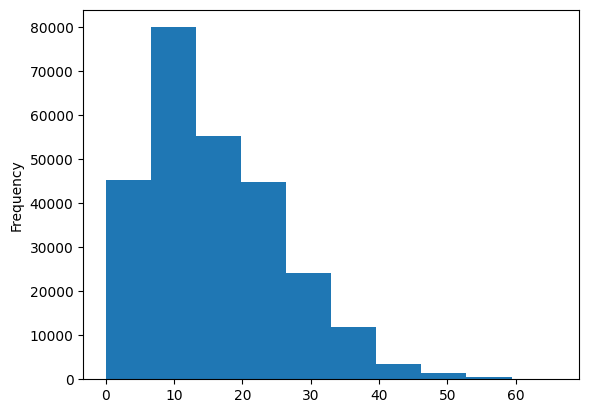

In [ ]:
months_to_default

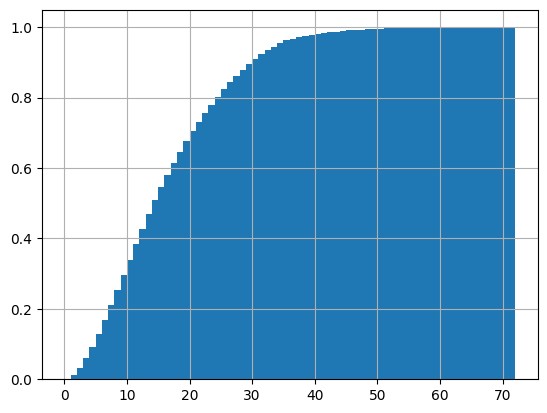

In [26]:
plt.hist(months_to_default, bins=range(0, 73), cumulative=True, density=True);
plt.grid(visible=True)

I have to make a tradeoff, instead of writing labels based on the loan_status, we will give the labels based on the cutoff no of months to loan maturity. I have chossen 24 months any loan older than this will be removed. I know this will cause mislabelling but it is still far better than what we did earlier.

In [28]:
latest_date = data['issue_d'].max()
latest_date

Timestamp('2018-12-01 00:00:00')

In [37]:
latest_period_int = latest_date.to_period('M').ordinal
issue_period_int = data['issue_d'].dt.to_period('M').astype(int)
age_of_loans = latest_period_int - issue_period_int

In [40]:
age_of_loans.max(), age_of_loans.min()

(np.int64(138), np.int64(0))

In [42]:
data = data.copy()

In [43]:
data['age_of_loans'] = age_of_loans

In [44]:
W = 24
ready_to_split = data[data['age_of_loans'] >= W]

In [48]:
data.shape

(2258241, 152)

In [46]:
ready_to_split.shape

(1320660, 152)

In [49]:
ready_to_split['issue_d'].max()

Timestamp('2016-12-01 00:00:00')

In [50]:
# building the labels
mask = (ready_to_split['loan_status'] != 'In Grace Period') & (ready_to_split['loan_status'] != 'Late (16-30 days)')
ready_to_split = ready_to_split[mask]

In [51]:
ready_to_split

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,age_of_loans
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,36
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,36
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,36
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,36
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260694,89885898,NaN,24000.0,24000.0,24000.0,60 months,12.79,543.50,C,C1,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,26
2260695,88977788,NaN,24000.0,24000.0,24000.0,60 months,10.49,515.74,B,B3,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,26
2260696,88985880,NaN,40000.0,40000.0,40000.0,60 months,10.49,859.56,B,B3,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,26
2260697,88224441,NaN,24000.0,24000.0,24000.0,60 months,14.49,564.56,C,C4,...,NaN,Cash,Y,Mar-2019,ACTIVE,Mar-2019,10000.0,44.82,1.0,26


In [52]:
# target settings
mask = (ready_to_split['loan_status'] == 'Charged Off') | (ready_to_split['loan_status'] == 'Default') | (ready_to_split['loan_status'] == 'Does not meet the credit policy. Status:Charged Off') | (ready_to_split['loan_status'] == 'Late (31-120 days)')
target = np.where(mask, 1, 0)

In [53]:
target

array([0, 0, 0, ..., 0, 1, 0], shape=(1316800,))

In [55]:
ready_to_split['target'] = target

In [57]:
(ready_to_split['target'].value_counts()/len(ready_to_split))*100

target
0    82.808931
1    17.191069
Name: count, dtype: float64

In [60]:
issue_d_group = ready_to_split.groupby(by=['issue_d'])['target'].mean()

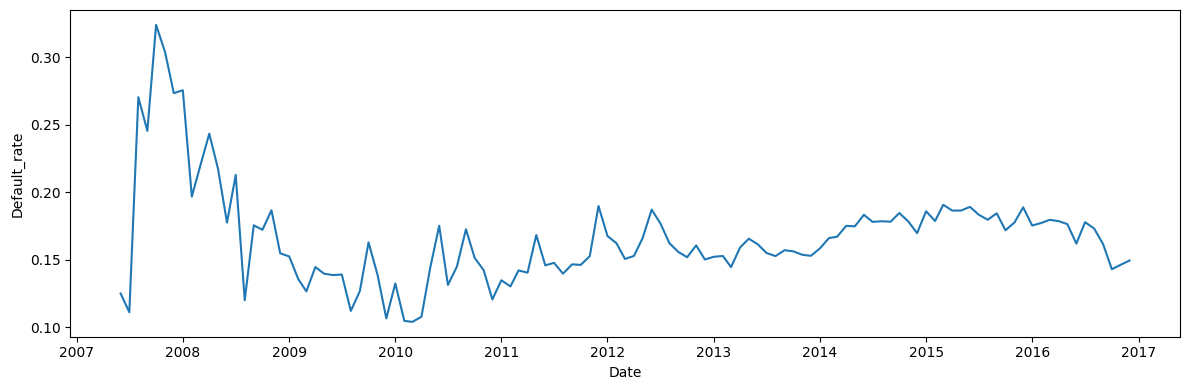

In [61]:
plt.figure(figsize=(12, 4))

plt.plot(issue_d_group)
plt.ylabel("Default_rate")
plt.xlabel('Date')
plt.tight_layout()